In [ ]:
# Ecommerce Sales Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('Amazon Sale Report.csv')
df.columns

C:\Users\abhin\AppData\Local\Temp\ipykernel_32492\2170669064.py:1: DtypeWarning: Columns (0: Unnamed: 22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Amazon Sale Report.csv')


Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='str')

In [25]:
df.info()

<class 'pandas.DataFrame'>
Index: 121149 entries, 0 to 128974
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Order ID       121149 non-null  str           
 1   Date           121149 non-null  datetime64[us]
 2   Status         121149 non-null  str           
 3   Fulfilment     121149 non-null  str           
 4   Sales Channel  121149 non-null  str           
 5   Category       121149 non-null  str           
 6   Qty            121149 non-null  int64         
 7   Amount         121149 non-null  float64       
 8   ship-state     121149 non-null  str           
 9   Month          121149 non-null  period[M]     
dtypes: datetime64[us](1), float64(1), int64(1), period[M](1), str(6)
memory usage: 10.2 MB


In [26]:
df.head()

,Order ID,Date,Status,Fulfilment,Sales Channel,Category,Qty,Amount,ship-state,Month
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Set,0,647.62,MAHARASHTRA,2022-04
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,kurta,1,406.00,KARNATAKA,2022-04
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,kurta,1,329.00,MAHARASHTRA,2022-04
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Western Dress,0,753.33,PUDUCHERRY,2022-04
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Top,1,574.00,TAMIL NADU,2022-04


In [27]:
df.tail()

,Order ID,Date,Status,Fulfilment,Sales Channel,Category,Qty,Amount,ship-state,Month
128970,406-6001380-7673107,2022-05-31,Shipped,Amazon,Amazon.in,kurta,1,517.0,TELANGANA,2022-05
128971,402-9551604-7544318,2022-05-31,Shipped,Amazon,Amazon.in,Set,1,999.0,HARYANA,2022-05
128972,407-9547469-3152358,2022-05-31,Shipped,Amazon,Amazon.in,Western Dress,1,690.0,TELANGANA,2022-05
128973,402-6184140-0545956,2022-05-31,Shipped,Amazon,Amazon.in,Set,1,1199.0,Gujarat,2022-05
128974,408-7436540-8728312,2022-05-31,Shipped,Amazon,Amazon.in,Set,1,696.0,CHHATTISGARH,2022-05


In [8]:

df.columns = df.columns.str.strip()


df = df.drop(columns=['index', 'Unnamed: 22'])

df.columns

Index(['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by'],
      dtype='str')

In [9]:
df = df[['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
         'Category', 'Qty', 'Amount', 'ship-state']]

df.head()

,Order ID,Date,Status,Fulfilment,Sales Channel,Category,Qty,Amount,ship-state
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Set,0,647.62,MAHARASHTRA
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,kurta,1,406.00,KARNATAKA
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,kurta,1,329.00,MAHARASHTRA
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Western Dress,0,753.33,PUDUCHERRY
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Top,1,574.00,TAMIL NADU


In [11]:

df['Date'] = pd.to_datetime(df['Date'])



In [12]:

df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

In [16]:
df.isnull().sum()



Order ID         0
Date             0
Status           0
Fulfilment       0
Sales Channel    0
Category         0
Qty              0
Amount           0
ship-state       0
dtype: int64

In [17]:
df = df.dropna()

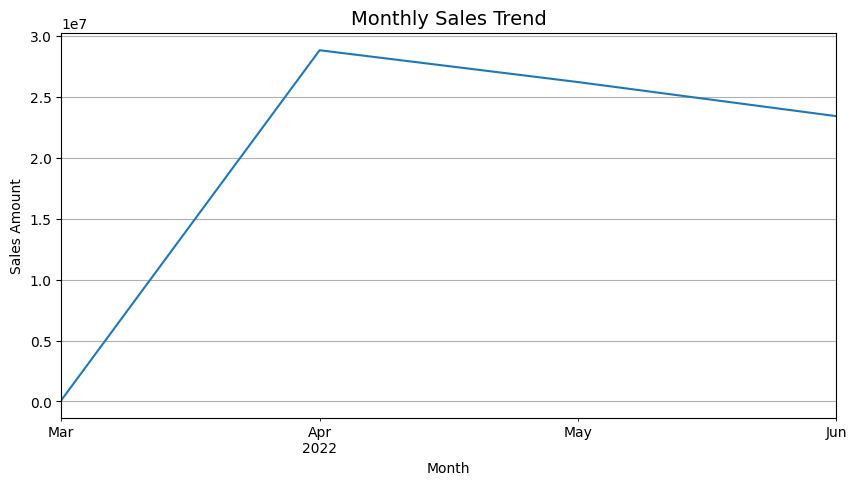

In [22]:
#01: Sales Trend Over Time

# Creating a month column
df['Month'] = df['Date'].dt.to_period('M')

# Grouping by month
monthly_sales = df.groupby('Month')['Amount'].sum()

import matplotlib.pyplot as plt

monthly_sales.plot(figsize=(10,5))
plt.title('Monthly Sales Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Sales Amount')
plt.grid()
plt.show()

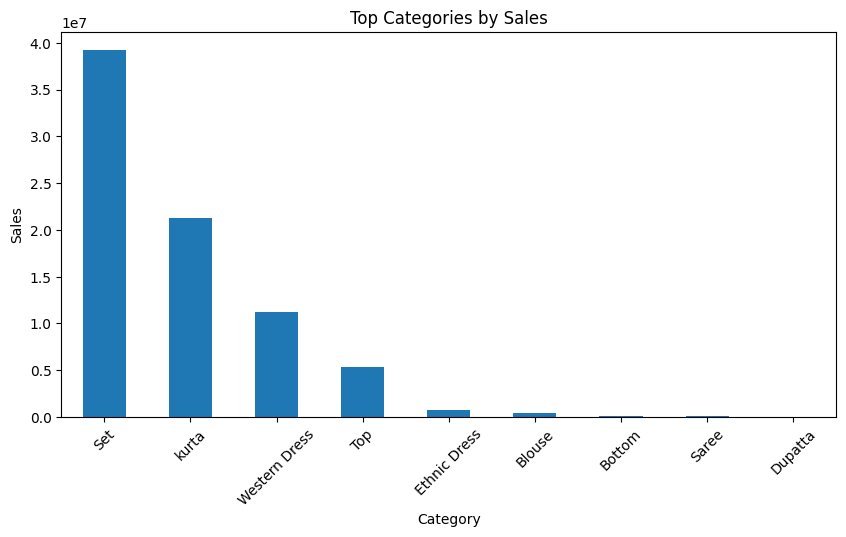

In [23]:
#02: Top Product Categories

category_sales.head(10).plot(kind='bar', figsize=(10,5))
plt.title('Top Categories by Sales')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

<Axes: title={'center': 'Top 10 States by Sales'}, xlabel='ship-state'>

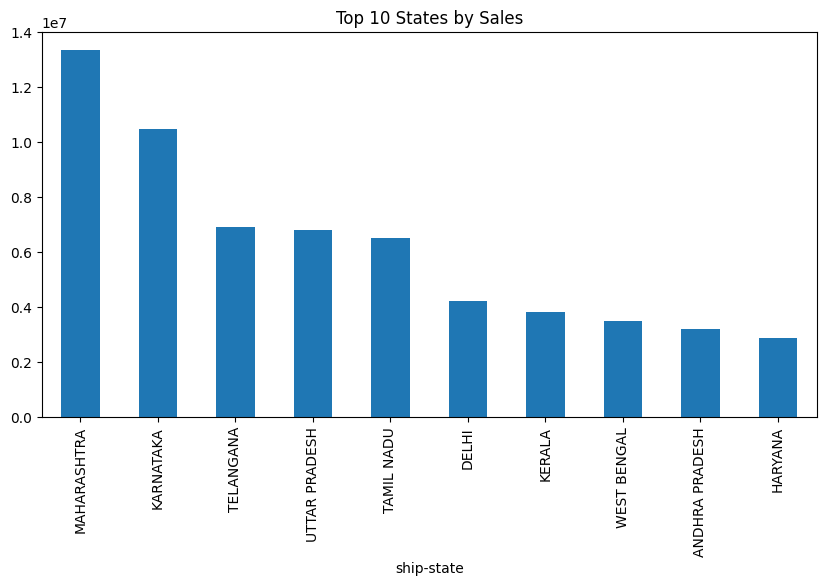

In [20]:
#03: State-wise Sales

state_sales = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)

state_sales.plot(kind='bar', figsize=(10,5), title='Top 10 States by Sales')

<Axes: title={'center': 'Order Status Distribution'}, xlabel='Status'>

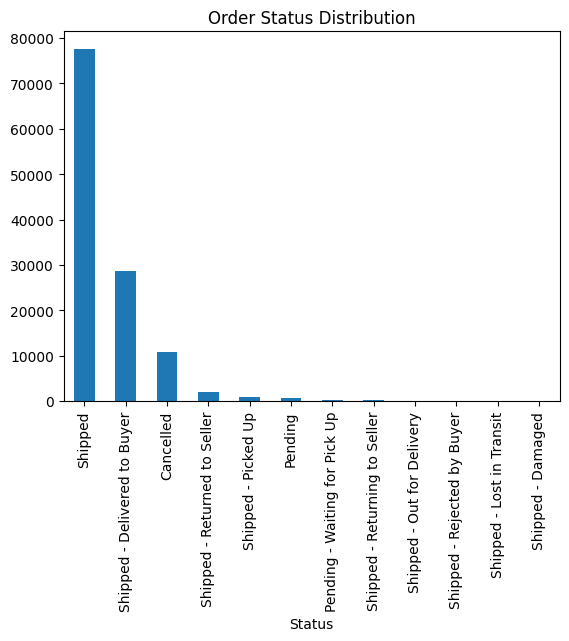

In [21]:
#04: Order Status Analysis

status_counts = df['Status'].value_counts()

status_counts.plot(kind='bar', title='Order Status Distribution')

<Axes: title={'center': 'Sales by Fulfilment'}, xlabel='Fulfilment'>

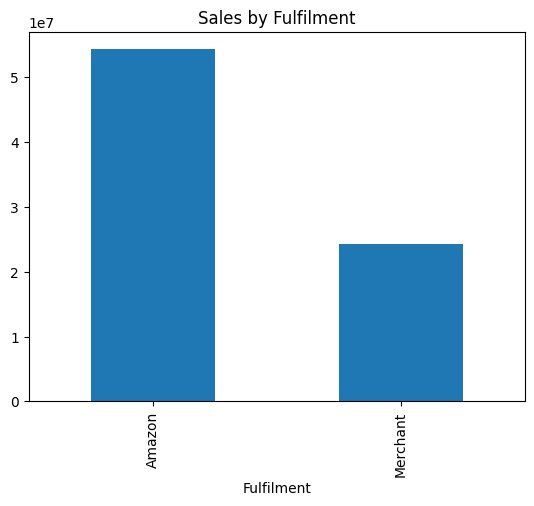

In [24]:
df.groupby('Fulfilment')['Amount'].sum().plot(kind='bar', title='Sales by Fulfilment')

## Key Insights

### 1. Sales Trend
Sales peaked in April 2022 and declined in the following months, indicating possible seasonality or reduced demand.

### 2. Top Category
The "Set" category generated the highest revenue, showing strong customer preference.

### 3. Top Performing State
Maharashtra recorded the highest sales, indicating a strong market presence in this region.

### 4. Business Recommendations
- Focus marketing efforts on Maharashtra
- Increase inventory for high-performing categories like "Set"
- Investigate reasons for sales decline after April